In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

## Task 1) Comparing Police Districts

> **Key Questions**

* Which district had the most crimes in 2022?
* Which had the least?


In [35]:
# load crime dataset of 2022 
df = pd.read_csv('Data/Chicago-Crime_2022.csv')

# rund the head
df.head()

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
0,12582293,01/01/2022 01:00:00 PM,THEFT,$500 AND UNDER,RESTAURANT,False,False,121,1.0,42.0,41.881884,-87.640060
1,12607313,01/01/2022 01:00:00 PM,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT $300 AND UNDER,BANK,False,False,811,8.0,23.0,41.787923,-87.769446
2,12585671,01/01/2022 01:00:00 AM,CRIMINAL DAMAGE,TO VEHICLE,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,531,5.0,9.0,41.687443,-87.604120
3,12592889,01/01/2022 01:00:00 AM,OTHER OFFENSE,HARASSMENT BY TELEPHONE,APARTMENT,False,False,412,4.0,8.0,41.734353,-87.585147
4,12584977,01/01/2022 01:00:00 AM,THEFT,$500 AND UNDER,OTHER (SPECIFY),False,False,1811,18.0,2.0,41.910818,-87.654560


In [36]:
# Check the datset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238858 entries, 0 to 238857
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    238858 non-null  int64  
 1   Date                  238858 non-null  object 
 2   Primary Type          238858 non-null  object 
 3   Description           238858 non-null  object 
 4   Location Description  238011 non-null  object 
 5   Arrest                238858 non-null  bool   
 6   Domestic              238858 non-null  bool   
 7   Beat                  238858 non-null  int64  
 8   District              238858 non-null  float64
 9   Ward                  238848 non-null  float64
 10  Latitude              233085 non-null  float64
 11  Longitude             233085 non-null  float64
dtypes: bool(2), float64(4), int64(2), object(4)
memory usage: 18.7+ MB


In [37]:
# Sum up the null values in the dataset
df.isnull().sum()

ID                         0
Date                       0
Primary Type               0
Description                0
Location Description     847
Arrest                     0
Domestic                   0
Beat                       0
District                   0
Ward                      10
Latitude                5773
Longitude               5773
dtype: int64

In [38]:
# set the date column as index and convert it to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# check the data type of the date column
df['Date'].dtype

C:\Users\noman\AppData\Local\Temp\ipykernel_16892\4057743705.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


dtype('<M8[ns]')

In [39]:
# set the date column as index 
df = df.set_index('Date')

In [40]:
# recheck the dataset 
df.head()

,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
Date,,,,,,,,,,,
2022-01-01 13:00:00,12582293,THEFT,$500 AND UNDER,RESTAURANT,False,False,121,1.0,42.0,41.881884,-87.640060
2022-01-01 13:00:00,12607313,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT $300 AND UNDER,BANK,False,False,811,8.0,23.0,41.787923,-87.769446
2022-01-01 01:00:00,12585671,CRIMINAL DAMAGE,TO VEHICLE,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,531,5.0,9.0,41.687443,-87.604120
2022-01-01 01:00:00,12592889,OTHER OFFENSE,HARASSMENT BY TELEPHONE,APARTMENT,False,False,412,4.0,8.0,41.734353,-87.585147
2022-01-01 01:00:00,12584977,THEFT,$500 AND UNDER,OTHER (SPECIFY),False,False,1811,18.0,2.0,41.910818,-87.654560


> ### `Which district had the most crimes in 2022?`

In [41]:
# value counts of the primary type of crime
df['District'].value_counts().to_frame().style.bar(color='red')

,count
District,
8.000000,14805
6.000000,14694
12.000000,14341
4.000000,13931
11.000000,13457
1.000000,13044
18.000000,12429
19.000000,12243
25.000000,11951


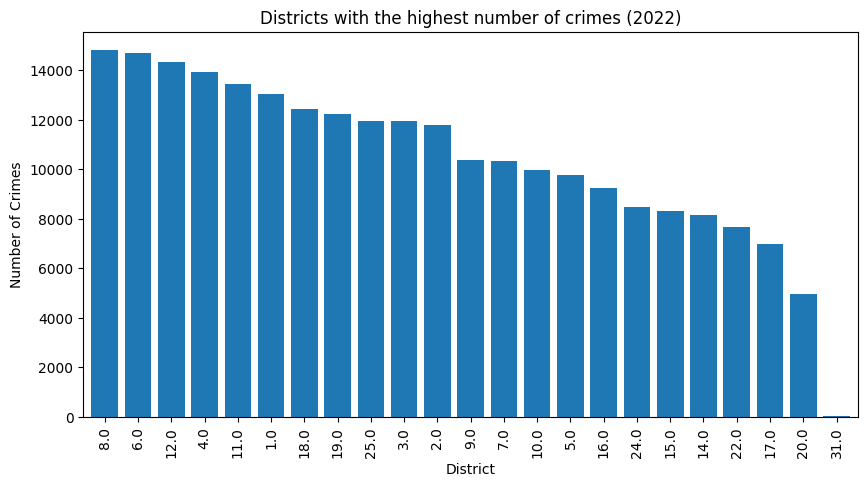

In [42]:
# check the distrcts with the highest number of crimes
df['District'].value_counts().plot(kind = 'bar', figsize = (10,5), title = 'Districts with the highest number of crimes (2022)', width = 0.8, ylabel = 'Number of Crimes');

* District 8.0 recorded the highest number of crimes in 2022, with over 15,000 cases.

> ### `Which had the least?`
* District 31.0 had the fewest crimes in 2022, with a count far below all other districts.

---

## Topic 2) Crimes Across the Years

> **Key Questions**

- **Overall Trend:** Is the total number of crimes increasing or decreasing across the years?
- **Outliers:** Are there any individual crimes doing the opposite — e.g., decreasing while overall crime rises, or vice-versa?

> ### `Is the total number of crimes increasing or decreasing across the years?`

In [43]:
# load all the files in the data folder and check the number of files
import glob

# grab all CSV files in the Data folder
files = glob.glob('Data/Chicago-Crime_*.csv')

# read each one and stack into a single DataFrame
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# convert Date to datetime and set as index
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date').sort_index()

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7713109 entries, 2001-01-01 00:00:00 to 2022-12-31 23:55:00
Data columns (total 11 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Primary Type          object 
 2   Description           object 
 3   Location Description  object 
 4   Arrest                bool   
 5   Domestic              bool   
 6   Beat                  int64  
 7   District              float64
 8   Ward                  float64
 9   Latitude              float64
 10  Longitude             float64
dtypes: bool(2), float64(4), int64(2), object(3)
memory usage: 603.2+ MB


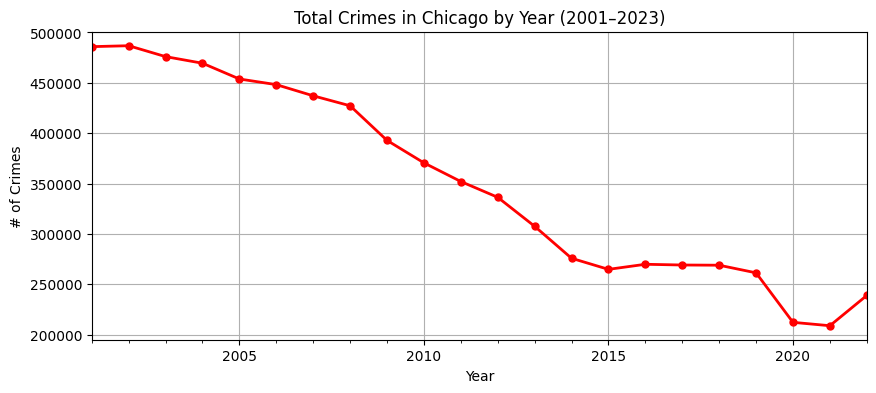

In [44]:
# check the trend of crimes over the years
df['District'].resample('YS').size().plot(
    figsize=(10, 4),
    title='Total Crimes in Chicago by Year (2001–2023)',
    ylabel='# of Crimes',
    xlabel='Year',
    color='red',
    marker='o',
    markersize=5,
    linewidth=2
).grid()

* The total number of crimes in Chicago has **declined steadily** over the years, falling from nearly 490,000 in 2001 to around 240,000 in 2022 — roughly a 50% drop.
* The decline plateaued briefly around 2015–2018, then fell sharply in 2020 (likely COVID-related), with a slight rebound in 2022.

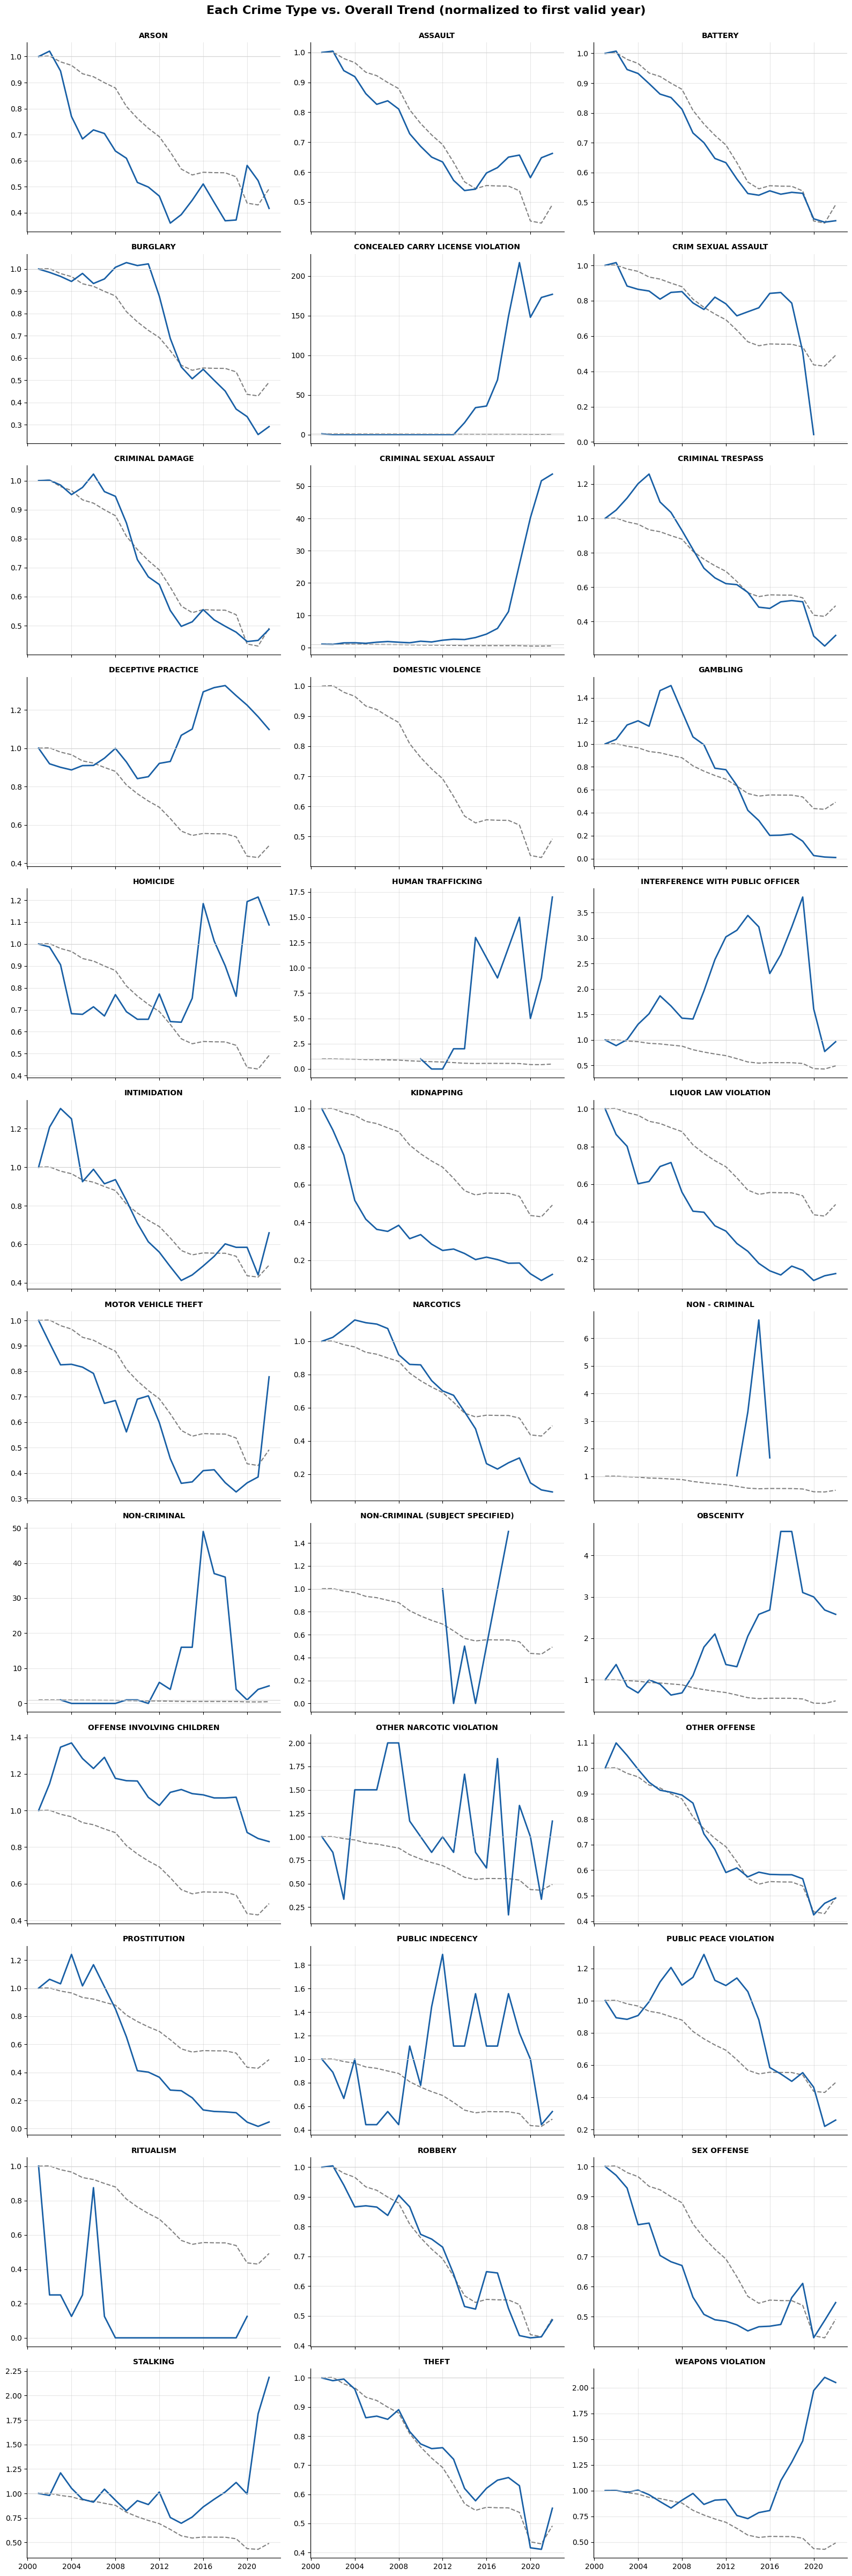

In [47]:
# build the trend table: one column per crime type, one row per year
trend = df.groupby('Primary Type', observed=True).resample('YS', include_groups=False).size().unstack(level=0)

# overall trend (total of all crimes per year)
overall = df.resample('YS').size()

# normalize each crime to ITS OWN first valid year (not the fixed 2001 row)
first_valid = trend.apply(lambda col: col[col.first_valid_index()])
normalized = trend / first_valid
overall_norm = overall / overall.iloc[0]

# set up the grid
types = normalized.columns
n = len(types)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), sharex=True)
axes = axes.flatten()

for i, crime in enumerate(types):
    ax = axes[i]
    ax.plot(overall_norm.index, overall_norm, color='gray',
            linestyle='--', linewidth=1.5, label='Overall trend')   # reference
    ax.plot(normalized.index, normalized[crime], color='#185FA5',
            linewidth=2, label=crime)                               # this crime type
    ax.set_title(crime, fontsize=10, fontweight='bold')
    ax.axhline(1.0, color='lightgray', linewidth=0.8)               # baseline
    ax.set_xlabel('')
    ax.grid(alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

# hide any leftover empty subplots
for j in range(n, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Each Crime Type vs. Overall Trend (normalized to first valid year)',
             fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

### Crimes Going Against the Overall Downward Trend

While total crime declined steadily, these crime types **increased** over the same period:

| Crime Type | Trend |
|------------|-------|
| Concealed Carry License Violation | ↑ sharp rise (~200×) |
| Criminal Sexual Assault | ↑ steep climb (~50×) |
| Human Trafficking | ↑ rising |
| Deceptive Practice | ↑ moderate rise |
| Homicide | ↑ spikes above baseline |
| Interference with Public Officer | ↑ strong rise |
| Obscenity | ↑ rise (~4×) |
| Stalking | ↑ sharp late rise |
| Weapons Violation | ↑ steady climb (~2×) |

**Note:** Some categories (e.g. Concealed Carry, Human Trafficking) started after 2001, so their large multiples partly reflect small early counts rather than pure growth.

---

## Topic 4) Comparing Months

> **Key Questions**

- **Overall Pattern:** What months have the most crime? What months have the least?
- **Outliers:** Are there any individual crimes that do *not* follow this pattern? If so, which crimes?

> ### `What months have the most crime? What months have the least?`

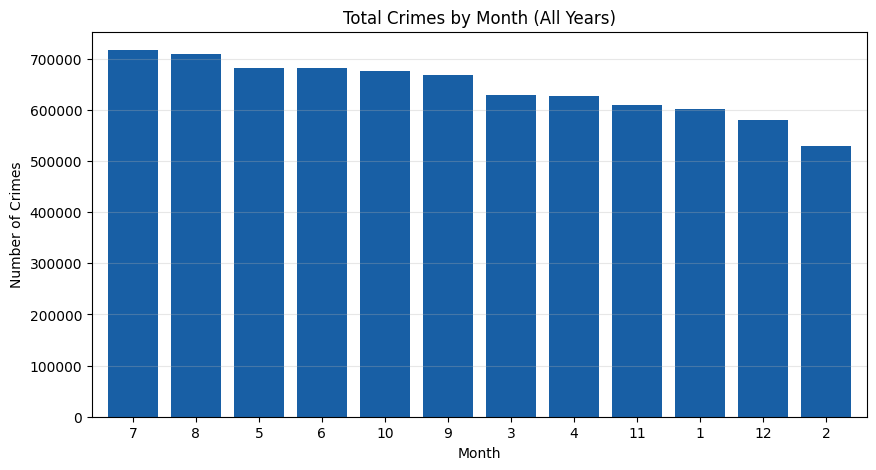

In [ ]:
# using plot()
df.groupby(df.index.month).size().sort_values(ascending=False).plot(kind='bar', figsize=(10, 5), title='Total Crimes by Month (All Years)', xlabel='Month', ylabel='Number of Crimes', width=0.8, color='#185FA5').grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.show()

In [ ]:
# using style method to show the real number of crimes in each month
df.groupby(df.index.month).size().sort_values(ascending = False).to_frame('Crimes').style.bar()

,Crimes
Date,
7,717232
8,710444
5,682932
6,681739
10,676285
9,668242
3,629704
4,627175
11,608961


* **Most crime:** July and August (summer) have the highest counts (~710,000+).
* **Least crime:** February and December (winter) have the lowest (~530,000).

> ### `Are there any individual crimes that do ** not ** follow this pattern? If so, which crimes?`

In [72]:
monthly = df.groupby([df.index.month, 'Primary Type']).size().unstack()
peak_month = monthly.idxmax()          # each crime's busiest month
print(peak_month.sort_values())


Primary Type
DOMESTIC VIOLENCE                     1
HUMAN TRAFFICKING                     1
DECEPTIVE PRACTICE                    1
PROSTITUTION                          1
RITUALISM                             1
OFFENSE INVOLVING CHILDREN            1
NON-CRIMINAL (SUBJECT SPECIFIED)      2
CRIMINAL TRESPASS                     3
NARCOTICS                             3
OTHER OFFENSE                         3
OTHER NARCOTIC VIOLATION              5
KIDNAPPING                            5
ASSAULT                               5
PUBLIC PEACE VIOLATION                5
WEAPONS VIOLATION                     5
LIQUOR LAW VIOLATION                  6
NON - CRIMINAL                        6
CRIM SEXUAL ASSAULT                   7
ARSON                                 7
BATTERY                               7
CRIMINAL SEXUAL ASSAULT               7
CRIMINAL DAMAGE                       7
SEX OFFENSE                           7
HOMICIDE                              7
THEFT                      

* **Most crimes follow the summer peak** (June–August), including Theft, Battery, Homicide, and Burglary.
* **Notable outliers that peak in other seasons:**
  * **Fall (Oct):** Motor Vehicle Theft, Robbery, Intimidation, Obscenity
  * **Spring (May):** Assault, Kidnapping, Weapons Violation
  * **Winter (Jan):** Deceptive Practice, Prostitution, Offense Involving Children